In [1]:
#uncomment and then run the following line to install the readlif package
! pip install liffile


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
! pip install matplotlib


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
! pip install -U 'napari[all]'


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [1]:
from liffile import LifFile


In [5]:
# reading a local .lif file
path = "./Texas red_1yo_WT.lif"

In [3]:
# importing some required libraries
import  matplotlib.pyplot as plt
import numpy as np
import napari 

In Python, you open a document using `open()` and a path

```python
file = open('path/to/file', 'r')
```
Normally the n you need to close it after your are done witth your work, in order not to corrupt the file.
```python
file.close()
```

So often, one opens and close the file using a special keyword `with` which keeps the file open until the end of teh `with` block, and then automatically closes it.
```python

with open('path/to/file', 'r') as file:
    # do something with the file
```

Something very similar can be done with `LifFile`.

In [6]:
with LifFile(path) as lif:
    for image in lif.images:
        print(image.name)
        print(image.shape)



Series001
(23, 2, 1024, 1024)
Series002
(906, 2, 512, 512)
Series003
(87, 2, 512, 512)
Series004
(105, 2, 1024, 1024)
Series005
(77, 2, 1024, 1024)
Series006
(103, 2, 1024, 1024)
Series007
(97, 2, 1024, 1024)
Series008
(115, 2, 1024, 1024)
Series009
(66, 2, 1024, 1024)
Series010
(68, 2, 1024, 1024)
Series011
(92, 2, 1024, 1024)
Series012
(88, 2, 1024, 1024)
Series013
(70, 2, 1024, 1024)


Selecting `Series008` as an example

In [7]:
# accessing a specific series and plottign all frames of that series
# oening th lif file  witout using `with` 
lifImages = LifFile(path) 
# pick a specific series
series = lifImages.images['Series008']

# lifImages.close() # we will need to close the file at the end....

Let's check the shape

In [9]:
series.frames.shape

(115, 2, 1024, 1024)

In [14]:
im = series.frames.asarray()
print(im.shape)
# we have changed types:
print("the series.frames object is",type(series.frames))
print("the im object is",type(im)  )
print("The numoy array has exactly the same shape", im.shape, series.frames.shape)

(115, 2, 1024, 1024)
the series.frames object is <class 'liffile.liffile.LifImageFrames'>
the im object is <class 'numpy.ndarray'>
The numoy array has exactly the same shape (115, 2, 1024, 1024) (115, 2, 1024, 1024)


Now that we have numpy array we can process it, and visualise it as we like using napari.

First we *slice* it meaning that we select a part it. In this case simply the part that corresponds to the first channel.

In [15]:

# now i can slice it a selct it like a numpy array
# specifically i take all the z, the 0th channel, and all the x and y
ch1 = im[:,0,:,:]

print(ch1.shape)

(115, 1024, 1024)


`ch1` is now a 3d numpy array.

Visualise is it `napari`

In [16]:
viewer = napari.Viewer()

Now that we have constructed a `viewer`, we can add images to it.

In [17]:
viewer.add_image(ch1, name="channel 1")

<Image layer 'channel 1' at 0x114706270>

Start with labelling the **nuclei**.

In [18]:
from skimage.measure import label
from scipy import ndimage

[Text(0.5, 0, 'Pixel Intensity'),
 Text(0, 0.5, 'Frequency (log scale)'),
 Text(0.5, 1.0, 'Histogram of Pixel Intensities')]

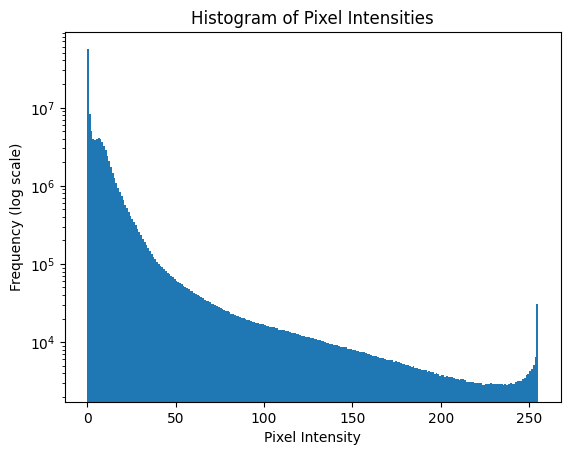

In [47]:
#histogram to check the intensity
plt.hist(ch1.flatten(), bins=np.arange(0, 256, 1))
plt.yscale('log')
plt.gca().set(xlabel='Pixel Intensity', ylabel='Frequency (log scale)', title='Histogram of Pixel Intensities')

In [ ]:
# from the histogram i choose a point between the blip at low intesity atnd teh kink of the historgram
thresh = 25. # you can tune this value.


62


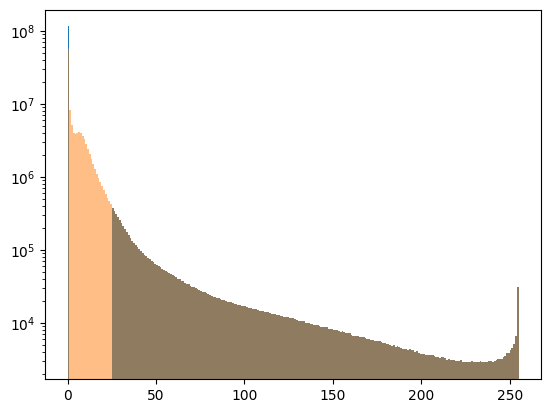

In [ ]:
# threshold by testing the image against the threshold
binary_nuclei = ch1 > thresh


viewer.add_image(binary_nuclei.astype(int), name='binary nuclei')



In [24]:
# remove the largest conneected components that are still bright after thresholding which are non-osteocytes
labeled_nuclei, num_features = label(binary_nuclei, return_num=True)


In [25]:
viewer.add_image(labeled_nuclei, name='labeled nuclei')

<Image layer 'labeled nuclei' at 0x14ea17750>

In [43]:

# # get the size of each connected component
component_sizes = np.bincount(labeled_nuclei.flatten())

# component_sizes # get the label of the largest connected component
largest_component_label = np.argmax(component_sizes[1:]) + 1  # add 1 to account for the background label
# # remove the largest connected component
binary_only_osteo_nuclei = labeled_nuclei.copy()
binary_only_osteo_nuclei[labeled_nuclei == largest_component_label] = 0

# viewer.add_image(binary_only_osteo_nuclei.astype(int), name='binary nuclei without largest component')

In [45]:
## chopping brutally]
chopped = binary_only_osteo_nuclei.copy()
chopped[:,600:,:] = 0

viewer.add_image(chopped.astype(int), name='chopped')

<Image layer 'chopped' at 0x1144a7d90>

Let's overlay the other channel to see what we lost and what we have

In [40]:
ch2 = im[:,1,:,:]

In [41]:
viewer.add_image(ch2, name='channel 2')

<Image layer 'channel 2' at 0x129ec60d0>